# Benchmarking Machine Learning Classifiers for Heart Disease Prediction

**Comparative Analysis of SVM, KNN, and Naive Bayes Classifiers**

Dataset: Personal Key Indicators of Heart Disease (CDC BRFSS 2020), via Kaggle
(kamilpytlak/personal-key-indicators-of-heart-disease)


In [1]:
import json
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

RANDOM_STATE = 42
%matplotlib inline

## 1. Load Data and Initial Exploration

The dataset (`heart_2020_cleaned.csv`) contains 319,795 rows and 18 columns,
with **no missing values**. The target variable `HeartDisease` is heavily
imbalanced: ~91.4% "No" vs ~8.6% "Yes".

In [2]:
df = pd.read_csv("heart_2020_cleaned.csv")
print(df.shape)
df.head()

(319795, 18)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [3]:
print(df.isnull().sum().sum(), "missing values")
print(df["HeartDisease"].value_counts())
print(df["HeartDisease"].value_counts(normalize=True) * 100)
df.describe()

0 missing values
HeartDisease
No     292422
Yes     27373
Name: count, dtype: int64
HeartDisease
No     91.440454
Yes     8.559546
Name: proportion, dtype: float64


,BMI,PhysicalHealth,MentalHealth,SleepTime
count,319795.000000,319795.00000,319795.000000,319795.000000
mean,28.325399,3.37171,3.898366,7.097075
std,6.356100,7.95085,7.955235,1.436007
min,12.020000,0.00000,0.000000,1.000000
25%,24.030000,0.00000,0.000000,6.000000
50%,27.340000,0.00000,0.000000,7.000000
75%,31.420000,2.00000,3.000000,8.000000
max,94.850000,30.00000,30.000000,24.000000


## 2. Stratified Sampling

The full dataset has ~320,000 rows. Training an SVM (particularly with an
RBF kernel, whose training cost scales roughly between O(n^2) and O(n^3))
on a training set of ~256,000 rows is computationally prohibitive on a
standard machine within a reasonable time budget.

A **stratified random sample of 15,000 rows** (preserving the original
~91.4% / 8.6% class ratio) is drawn and used for **all three classifiers**,
ensuring a fair, apples-to-apples comparison.

In [4]:
SAMPLE_SIZE = 15000
df_sample, _ = train_test_split(
    df, train_size=SAMPLE_SIZE, stratify=df["HeartDisease"], random_state=RANDOM_STATE
)
print(df_sample.shape)
df_sample["HeartDisease"].value_counts()

(15000, 18)


HeartDisease
No     13716
Yes     1284
Name: count, dtype: int64

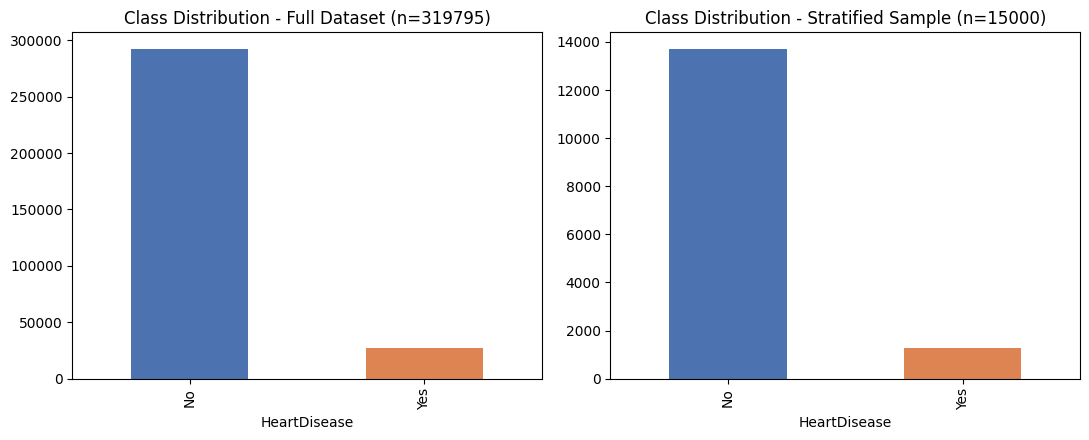

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
df["HeartDisease"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title(f"Class Distribution - Full Dataset (n={len(df)})")
df_sample["HeartDisease"].value_counts().plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title(f"Class Distribution - Stratified Sample (n={SAMPLE_SIZE})")
plt.tight_layout()
plt.show()

## 3. Preprocessing

Steps applied:
1. Encode the target `HeartDisease` (Yes -> 1, No -> 0).
2. Map simple binary Yes/No columns (Smoking, AlcoholDrinking, Stroke,
   DiffWalking, PhysicalActivity, Asthma, KidneyDisease, SkinCancer, Sex)
   to 0/1.
3. Ordinal-encode `GenHealth` (Poor < Fair < Good < Very good < Excellent)
   and `AgeCategory` (ordered age brackets), since these have a natural order.
4. One-hot (dummy) encode the remaining nominal categorical columns
   (`Race`, `Diabetic`) with `drop_first=True`.
5. Split into an 80% training set and a 20% testing set (stratified on the
   target to preserve class balance).
6. Apply `StandardScaler` to the continuous numerical columns
   (BMI, PhysicalHealth, MentalHealth, SleepTime, AgeCategory, GenHealth)
   fitted **only on the training data** and applied to both train and test
   sets to avoid data leakage.

In [6]:
data = df_sample.copy()

# Target
data["HeartDisease"] = data["HeartDisease"].map({"Yes": 1, "No": 0})

# Binary Yes/No columns
binary_cols = ["Smoking", "AlcoholDrinking", "Stroke", "DiffWalking",
                "PhysicalActivity", "Asthma", "KidneyDisease", "SkinCancer"]
for col in binary_cols:
    data[col] = data[col].map({"Yes": 1, "No": 0})

data["Sex"] = data["Sex"].map({"Male": 1, "Female": 0})

# Ordinal encodings
genhealth_map = {"Poor": 0, "Fair": 1, "Good": 2, "Very good": 3, "Excellent": 4}
data["GenHealth"] = data["GenHealth"].map(genhealth_map)

age_categories = sorted(data["AgeCategory"].unique(),
                         key=lambda x: int(x.split(" ")[0].replace("+", "").split("-")[0]))
age_map = {cat: i for i, cat in enumerate(age_categories)}
data["AgeCategory"] = data["AgeCategory"].map(age_map)

# One-hot encode remaining nominal columns
data = pd.get_dummies(data, columns=["Race", "Diabetic"], drop_first=True)

print(f"Number of features after encoding: {data.shape[1] - 1}")
data.head()

Number of features after encoding: 23


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,...,KidneyDisease,SkinCancer,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
168780,0,25.83,0,0,0,1.0,0.0,0,1,9,...,0,0,False,False,False,False,True,False,False,False
93783,0,25.09,1,0,0,0.0,15.0,0,1,5,...,0,0,False,False,False,False,True,False,False,False
637,0,29.95,0,0,0,2.0,0.0,0,0,9,...,0,1,False,False,False,False,True,False,False,False
306306,1,32.69,0,0,0,0.0,0.0,0,1,10,...,0,1,False,False,False,False,True,False,False,False
58989,0,23.06,0,0,0,0.0,0.0,0,1,9,...,0,1,False,False,False,False,True,False,False,False


In [7]:
X = data.drop(columns=["HeartDisease"])
y = data["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)

numeric_cols = ["BMI", "PhysicalHealth", "MentalHealth", "SleepTime",
                 "AgeCategory", "GenHealth"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled = X_train_scaled.astype(float)
X_test_scaled = X_test_scaled.astype(float)

Train: (12000, 23)  Test: (3000, 23)


### Why is scaling essential for SVM and KNN but optional for Naive Bayes?

- **KNN** relies directly on Euclidean (or other) **distances** between
  feature vectors. If one feature (e.g. `BMI`, range ~12-95) has a much
  larger numeric range than another (e.g. `PhysicalHealth`, range 0-30, or
  a binary 0/1 flag), it will dominate the distance calculation and
  effectively drown out the contribution of the smaller-range features,
  regardless of their predictive value. Standardizing all features to zero
  mean / unit variance ensures every feature contributes proportionally.

- **SVM** (especially with the RBF kernel) computes similarity via the
  kernel function, which for RBF is `exp(-gamma * ||x - x'||^2)` -- again a
  distance-based quantity. The optimization of the maximum-margin hyperplane
  is also sensitive to feature scale: features with large numeric ranges can
  dominate the margin calculation and slow or destabilize convergence of the
  underlying quadratic optimization.

- **Gaussian Naive Bayes**, by contrast, models each feature
  **independently** with its own per-class mean and variance
  (`P(x_i | class)` is a univariate Gaussian fitted separately for every
  feature). Multiplying probabilities together is invariant to the absolute
  scale of each feature, because the model estimates its own variance for
  each feature from the training data. A linear shift/scale transformation of
  a feature simply rescales the parameters of its Gaussian without changing
  the relative likelihood ratios between classes. Hence, scaling has no
  meaningful effect on Naive Bayes predictions, making it optional.

## 4. Model Implementation & Hyperparameter Tuning

A shared `evaluate_model` helper trains a model, predicts on the test set,
and reports Accuracy, Precision, Recall, F1-score and the Confusion Matrix.

In [8]:
results = []
confusion_matrices = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, hyperparams):
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)
    cm = confusion_matrix(y_te, y_pred)

    print(f"--- {name} ({hyperparams}) ---")
    print(f"Train time: {train_time:.2f}s")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(classification_report(y_te, y_pred, target_names=["No Disease", "Disease"], zero_division=0))

    results.append({"Model": name, "Hyperparameters": hyperparams, "Accuracy": round(acc, 4),
                     "Precision": round(prec, 4), "Recall": round(rec, 4), "F1-Score": round(f1, 4),
                     "TrainTimeSec": round(train_time, 2)})
    return cm, f1

### 4.1 Support Vector Machine (SVM)

Two kernels are tested: **linear** and **RBF**, both with `C=1.0`.

In [9]:
cm_svm_linear, f1_svm_linear = evaluate_model(
    "SVM", SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE),
    X_train_scaled, y_train, X_test_scaled, y_test, "Kernel=Linear, C=1.0")
confusion_matrices["SVM (Linear, C=1.0)"] = cm_svm_linear

--- SVM (Kernel=Linear, C=1.0) ---
Train time: 1.40s
Accuracy:  0.9143
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000
              precision    recall  f1-score   support

  No Disease       0.91      1.00      0.96      2743
     Disease       0.00      0.00      0.00       257

    accuracy                           0.91      3000
   macro avg       0.46      0.50      0.48      3000
weighted avg       0.84      0.91      0.87      3000



In [10]:
cm_svm_rbf, f1_svm_rbf = evaluate_model(
    "SVM", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE),
    X_train_scaled, y_train, X_test_scaled, y_test, "Kernel=RBF, C=1.0, gamma=scale")
confusion_matrices["SVM (RBF, C=1.0)"] = cm_svm_rbf

--- SVM (Kernel=RBF, C=1.0, gamma=scale) ---
Train time: 2.78s
Accuracy:  0.9160
Precision: 0.6923
Recall:    0.0350
F1-score:  0.0667
              precision    recall  f1-score   support

  No Disease       0.92      1.00      0.96      2743
     Disease       0.69      0.04      0.07       257

    accuracy                           0.92      3000
   macro avg       0.80      0.52      0.51      3000
weighted avg       0.90      0.92      0.88      3000



### 4.2 K-Nearest Neighbors (KNN)

Three values of K are tested: **3, 5, and 11**, to explore the
bias-variance trade-off (small K -> low bias / high variance,
large K -> higher bias / lower variance, smoother decision boundary).

In [11]:
knn_cms, knn_f1s = {}, {}
for k in [3, 5, 11]:
    cm_knn, f1_knn = evaluate_model(
        "KNN", KNeighborsClassifier(n_neighbors=k),
        X_train_scaled, y_train, X_test_scaled, y_test, f"K={k}")
    knn_cms[k] = cm_knn
    knn_f1s[k] = f1_knn
    confusion_matrices[f"KNN (K={k})"] = cm_knn

--- KNN (K=3) ---
Train time: 0.00s
Accuracy:  0.8973
Precision: 0.2661
Recall:    0.1128
F1-score:  0.1585
              precision    recall  f1-score   support

  No Disease       0.92      0.97      0.95      2743
     Disease       0.27      0.11      0.16       257

    accuracy                           0.90      3000
   macro avg       0.59      0.54      0.55      3000
weighted avg       0.87      0.90      0.88      3000

--- KNN (K=5) ---
Train time: 0.00s
Accuracy:  0.9063
Precision: 0.3182
Recall:    0.0817
F1-score:  0.1300
              precision    recall  f1-score   support

  No Disease       0.92      0.98      0.95      2743
     Disease       0.32      0.08      0.13       257

    accuracy                           0.91      3000
   macro avg       0.62      0.53      0.54      3000
weighted avg       0.87      0.91      0.88      3000



--- KNN (K=11) ---
Train time: 0.00s
Accuracy:  0.9160
Precision: 0.5926
Recall:    0.0623
F1-score:  0.1127
              precision    recall  f1-score   support

  No Disease       0.92      1.00      0.96      2743
     Disease       0.59      0.06      0.11       257

    accuracy                           0.92      3000
   macro avg       0.76      0.53      0.53      3000
weighted avg       0.89      0.92      0.88      3000



### 4.3 Gaussian Naive Bayes

Default scikit-learn `GaussianNB` (no hyperparameter tuning).

In [12]:
cm_nb, f1_nb = evaluate_model(
    "Naive Bayes", GaussianNB(),
    X_train_scaled, y_train, X_test_scaled, y_test, "Default Gaussian (var_smoothing=1e-9)")
confusion_matrices["Naive Bayes (Default)"] = cm_nb

--- Naive Bayes (Default Gaussian (var_smoothing=1e-9)) ---
Train time: 0.01s
Accuracy:  0.8283
Precision: 0.2646
Recall:    0.5642
F1-score:  0.3602
              precision    recall  f1-score   support

  No Disease       0.95      0.85      0.90      2743
     Disease       0.26      0.56      0.36       257

    accuracy                           0.83      3000
   macro avg       0.61      0.71      0.63      3000
weighted avg       0.90      0.83      0.85      3000



## 5. Results Summary

In [13]:
results_df = pd.DataFrame(results)
results_df

,Model,Hyperparameters,Accuracy,Precision,Recall,F1-Score,TrainTimeSec
0,SVM,"Kernel=Linear, C=1.0",0.9143,0.0000,0.0000,0.0000,1.40
1,SVM,"Kernel=RBF, C=1.0, gamma=scale",0.9160,0.6923,0.0350,0.0667,2.78
2,KNN,K=3,0.8973,0.2661,0.1128,0.1585,0.00
3,KNN,K=5,0.9063,0.3182,0.0817,0.1300,0.00
4,KNN,K=11,0.9160,0.5926,0.0623,0.1127,0.00
5,Naive Bayes,Default Gaussian (var_smoothing=1e-9),0.8283,0.2646,0.5642,0.3602,0.01


In [14]:
# Best configuration per model family (by F1-score)
best_svm_row = max([r for r in results if r["Model"] == "SVM"], key=lambda r: r["F1-Score"])
best_knn_row = max([r for r in results if r["Model"] == "KNN"], key=lambda r: r["F1-Score"])
nb_row = [r for r in results if r["Model"] == "Naive Bayes"][0]

summary_df = pd.DataFrame([best_svm_row, best_knn_row, nb_row])
summary_df

,Model,Hyperparameters,Accuracy,Precision,Recall,F1-Score,TrainTimeSec
0,SVM,"Kernel=RBF, C=1.0, gamma=scale",0.9160,0.6923,0.0350,0.0667,2.78
1,KNN,K=3,0.8973,0.2661,0.1128,0.1585,0.00
2,Naive Bayes,Default Gaussian (var_smoothing=1e-9),0.8283,0.2646,0.5642,0.3602,0.01


## 6. Confusion Matrices

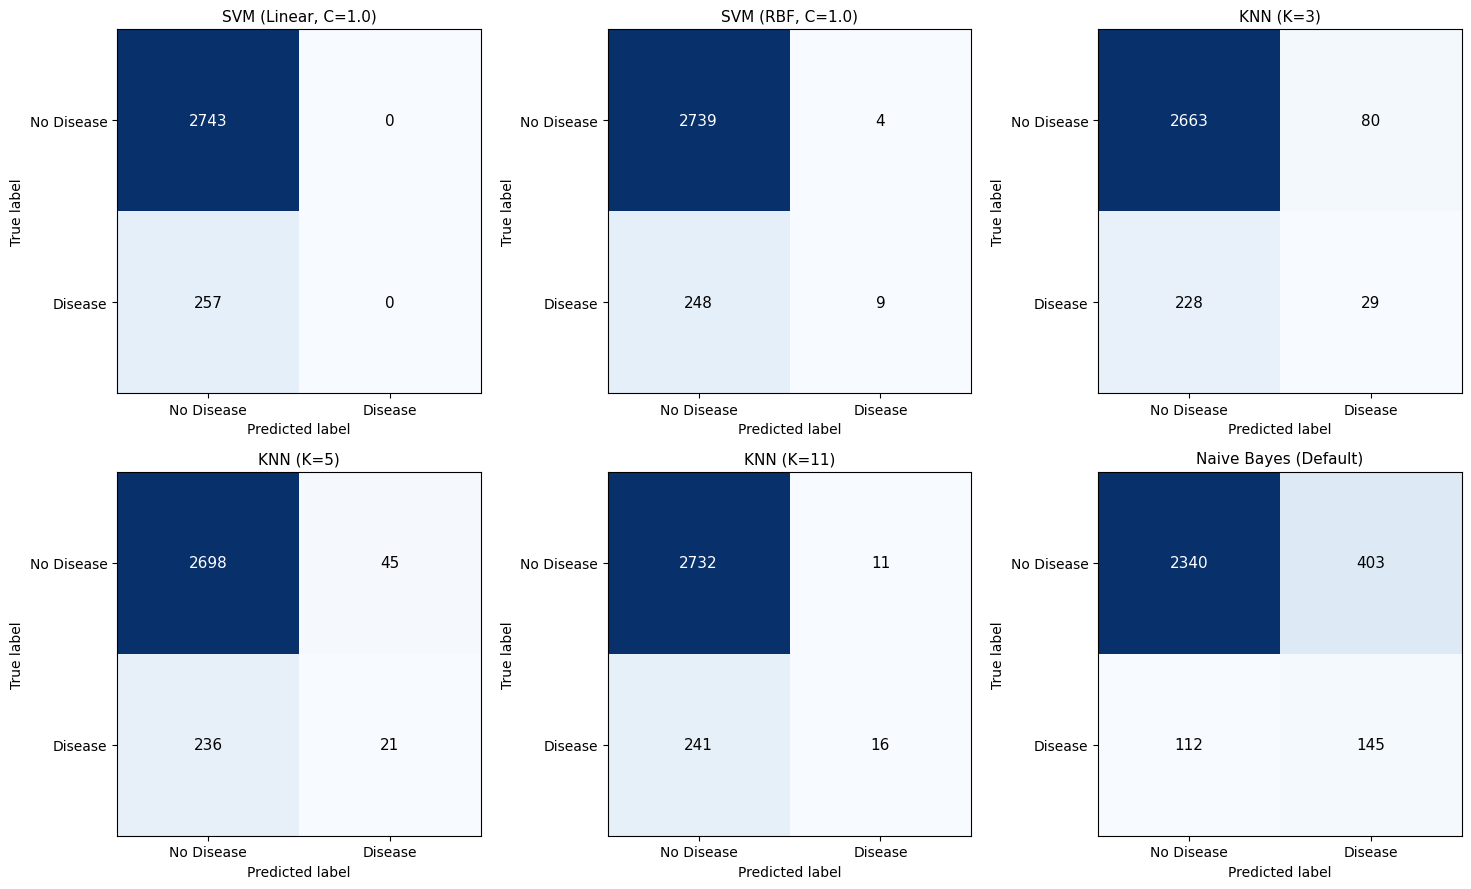

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for ax, (label, cm) in zip(axes, confusion_matrices.items()):
    ax.imshow(cm, cmap="Blues")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["No Disease", "Disease"])
    ax.set_yticklabels(["No Disease", "Disease"])
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"), ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black", fontsize=11)
plt.tight_layout()
plt.show()

## 7. Discussion

See the accompanying technical report for full discussion of comparative
results, clinical implications of false positives vs. false negatives, and
recommendations for deployment and future work (e.g. SMOTE for class
imbalance, ensemble methods).